### Name : Rohan Sanjay Satkar 
### PID : 246050
### Date : 23/02/26
### Exp No : 06
### Title :  Classification of Credit Card Default Risk using Support Vector Machine


In [1]:
%pip install pandas scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score , recall_score , f1_score

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: c:\program files\python39\python.exe -m pip install --upgrade pip


In [2]:
data = pd.read_csv("credit.csv" , skiprows=1)
data = data.sample(5000,random_state=42)

print(data.columns)

data.drop(columns=['ID'],inplace = True)
print(data.columns)
print(data.columns[2])  # prints second column name
data.info()

Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
EDUCATION
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER         

In [3]:
y = data['default payment next month']
x = data [['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [4]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size=0.3,random_state=42
)


In [5]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [8]:
model = {
    "Linear SVM" : SVC(kernel='linear' , C = 1 , class_weight='balanced'),
    "Polynomial SVM" : SVC(kernel = 'poly',
                           degree = 2,
                           C = 1,
                           gamma = 'scale',
                           class_weight = 'balanced'),
    "RBF SVM" : SVC(kernel="rbf",
                    C=5,
                    gamma=0.1,
                    class_weight='balanced')
}

for name,model in model.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1_Score:", f1_score(y_test, y_pred))
print("Accuracy Score Test:", accuracy_score(y_test, y_pred))
print("Accuracy Score Train:", accuracy_score(y_train, y_pred_train))
    

Confusion Matrix:
 [[560 599]
 [166 175]]
Precision: 0.22609819121447028
Recall: 0.5131964809384164
F1_Score: 0.31390134529147984
Accuracy Score Test: 0.49
Accuracy Score Train: 0.5017142857142857



Linear SVM
Confusion Matrix:
 [[ 103 1056]
 [  34  307]]
Precision: 0.2252384446074835
Recall: 0.9002932551319648
F1 Score: 0.36032863849765256
Accuracy Score Test: 0.2733333333333333
Accuracy Score Train: 0.2797142857142857


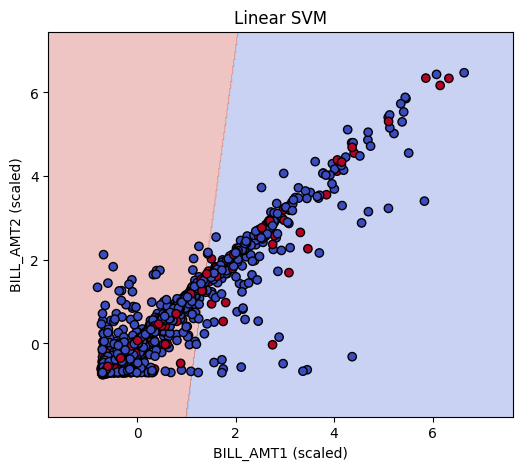


Polynomial SVM
Confusion Matrix:
 [[  35 1124]
 [   8  333]]
Precision: 0.22855181880576528
Recall: 0.9765395894428153
F1 Score: 0.3704115684093437
Accuracy Score Test: 0.24533333333333332
Accuracy Score Train: 0.24114285714285713


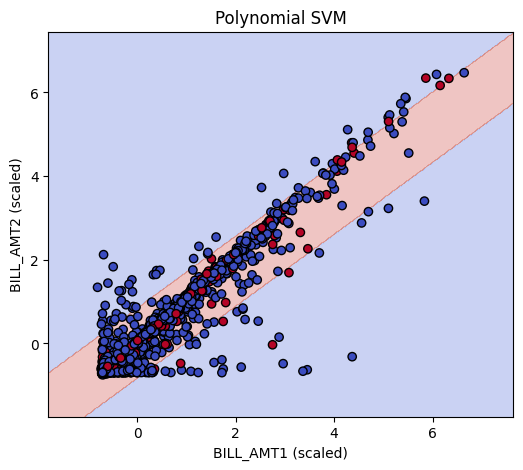


RBF (Gaussian) SVM
Confusion Matrix:
 [[560 599]
 [166 175]]
Precision: 0.22609819121447028
Recall: 0.5131964809384164
F1 Score: 0.31390134529147984
Accuracy Score Test: 0.49
Accuracy Score Train: 0.5017142857142857


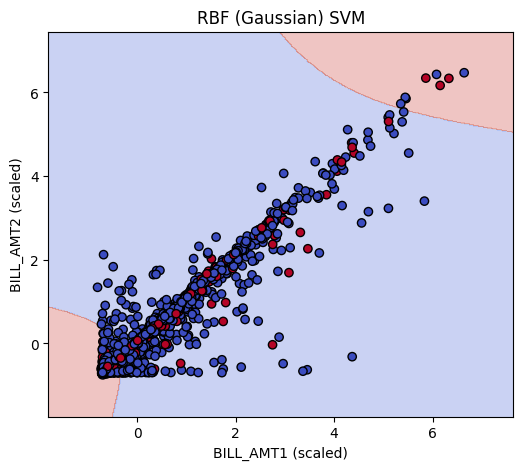

In [17]:
# ---------------------------
# Define Models  ✅ MOVE THIS UP
# ---------------------------

models = {
    "Linear SVM": SVC(kernel='linear', C=1, class_weight='balanced'),
    "Polynomial SVM": SVC(kernel='poly', degree=2, C=1, gamma='scale', class_weight='balanced'),
    "RBF (Gaussian) SVM": SVC(kernel='rbf', C=5, gamma=0.1, class_weight='balanced')
}


# ---------------------------
# Plot Function
# ---------------------------

def plot_boundary(model, title):
    h = 0.02

    x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
    y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    plt.scatter(
        x_train[:, 0],
        x_train[:, 1],
        c=y_train,
        cmap=plt.cm.coolwarm,
        edgecolors='k'
    )

    plt.title(title)
    plt.xlabel("BILL_AMT1 (scaled)")
    plt.ylabel("BILL_AMT2 (scaled)")
    plt.show()


# ---------------------------
# Train, Evaluate & Plot
# ---------------------------

for name, clf in models.items():
    clf.fit(x_train, y_train)

    y_pred = clf.predict(x_test)
    y_pred_train = clf.predict(x_train)

    print("\n==============================")
    print(name)
    print("==============================")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Accuracy Score Test:", accuracy_score(y_test, y_pred))
    print("Accuracy Score Train:", accuracy_score(y_train, y_pred_train))

    plot_boundary(clf, name)

In [ ]:
`